In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

from bio_network.engine.neurons import IzhikevichPopulation
from bio_network.engine.scheduler import simulate
from bio_network.engine.synapses_sparse import SparseSynapses
from bio_network.viz.raster import plot_population_rate, plot_raster

N_EXC, N_INH = 800, 200
N = N_EXC + N_INH
SEED = 42
GAIN = 8.0
OUTPUT_DIR = os.path.join(os.getcwd(), "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory:", OUTPUT_DIR)


Output directory: A:\Bio Network\notebooks\output


# Milestone 2 -- self-organizing STDP on the sparse event-driven engine

STDP (spike-timing-dependent plasticity) is the local, unsupervised learning
rule at the heart of the roadmap's M2 milestone: a synapse strengthens when
the pre-synaptic spike *arrives* just before the post-synaptic neuron fires
(causal, LTP) and weakens in the reverse order (anti-causal, LTD), following
the qualitative window of **Bi & Poo (1998)** with the stable normalized
bounds of **Song, Miller & Abbott (2000)**.

Three design choices make it run event-driven and stable:

1. **Arrival-time causality.** The plasticity is computed against the
   *magnitude of the axonal delay* -- the millisecond the spike reaches the
   post-synaptic neuron -- not the millisecond it was emitted. This is the
   biologically meaningful ordering and is what the window functions see.
2. **Hard bounds and asymmetric amplitudes.** Exc-ex weights are clamped to
   `[0, 1]`, and depression is slightly stronger than potentiation
   (`A- = 0.12 > A+ = 0.10`). A heavier LTD keeps the recurrent network from
   running away -- the hallmark Song-Miller-Abbott stability mechanism.
3. **Excitatory-only plasticity.** Inhibitory weights are frozen. E/I balance
   stays intact, which is what keeps the network in the stable active regime.

All training below uses `gain = 8` so there is headroom under the ~160 Hz
avalanche regime before LTP raises the effective gain.


In [2]:
def make_network():
    return (
        IzhikevichPopulation(seed=SEED),
        SparseSynapses(n_excit=N_EXC, n_inhib=N_INH, out_degree=100, seed=SEED, gain=GAIN),
    )

def exc_weight_distribution(synapses):
    return synapses.weights[: synapses.n_excit * synapses.out_degree]

def exc_mean(synapses, pre, post):
    collected = []
    for pre_i in range(pre[0], pre[1]):
        start, end = int(synapses.offsets[pre_i]), int(synapses.offsets[pre_i + 1])
        tg = synapses.targets[start:end]
        sel = (tg >= post[0]) & (tg < post[1])
        if sel.any():
            collected.append(synapses.weights[start:end][sel])
    return float(np.concatenate(collected).mean()) if collected else 0.0


## Experiment 1 -- hallmark stability

Drive the network with the default noise, learning on, for 30 s. A healthy
STDP run must (a) stay in the active regime the whole time, (b) never produce
NaN, and (c) shape the excitatory weights into a bimodal distribution -- many
synapses pushed to zero, many pushed to one, few in between.


spikes: 126911
mean exc rate: 5.28 Hz
mean inh rate: 0.03 Hz
per-second mean rate range: [4.07, 4.87] Hz
exc weights: min 0.000 max 1.000 mean 0.583
finite: True


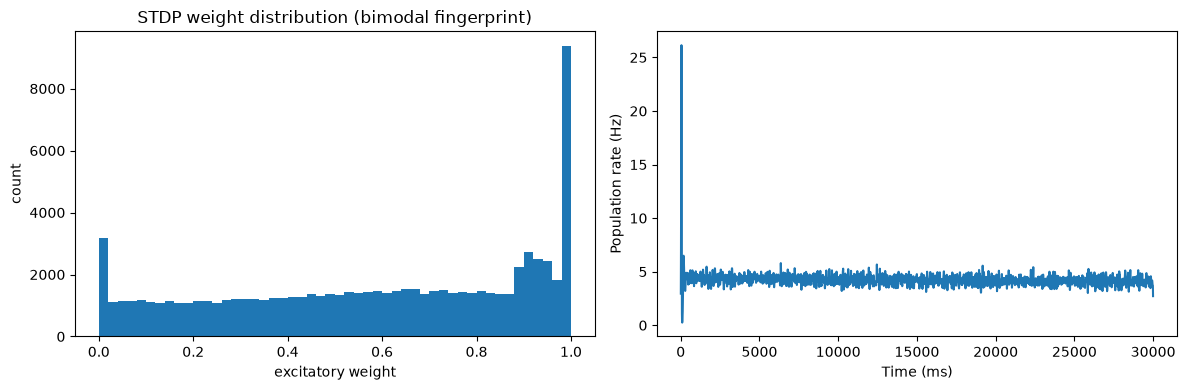

In [3]:
from bio_network.engine.scheduler import simulate

population, synapses = make_network()
rec = simulate(population, synapses, T_ms=30000, engine="sparse", learning=True)

rates = rec.mean_rates_hz()
exc = exc_weight_distribution(synapses)
seg = 1000
counts, _ = np.histogram(rec.times_ms, bins=30, range=(0, 30000))
seg_rate = counts / 1.0 / N

print(f"spikes: {rec.times_ms.size}")
print(f"mean exc rate: {rates[:N_EXC].mean():.2f} Hz")
print(f"mean inh rate: {rates[N_EXC:].mean():.2f} Hz")
print(f"per-second mean rate range: [{seg_rate.min():.2f}, {seg_rate.max():.2f}] Hz")
print(f"exc weights: min {exc.min():.3f} max {exc.max():.3f} mean {exc.mean():.3f}")
print(f"finite: {np.all(np.isfinite(population.v)) and np.all(np.isfinite(population.u))}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(exc, bins=np.arange(0, 1.01, 0.02), color="tab:blue")
axes[0].set_xlabel("excitatory weight"); axes[0].set_ylabel("count")
axes[0].set_title("STDP weight distribution (bimodal fingerprint)")
plot_population_rate(rec, ax=axes[1])
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "m2_hallmark.png"), dpi=120)
plt.show()


## Experiment 2 -- fire together, wire together

Group A (0..49) is driven with a brief poke, and group B (50..99) fires about
one axonal-delay later, every 200 ms; group C (100..149) only sees noise. STDP
should strengthen A->B over the 20 s training run while A->C stays at
baseline, then hold those weights during a frozen 2 s test phase.


In [4]:
from bio_network.engine.scheduler import simulate

PERIOD, W_A, LEAD, AMP = 200, 3, 25, 20.0
GROUP_A, GROUP_B, GROUP_C = (0, 50), (50, 100), (100, 150)

def pair_pulse_stim(a, b):
    rng = np.random.default_rng(SEED)
    scale = np.ones(N); scale[:N_EXC] = 5.0; scale[N_EXC:] = 2.0
    def _stim(t, n_neurons):
        base = scale * rng.standard_normal(N)
        phase = int(t) % PERIOD
        if phase < W_A:
            base[a[0]:a[1]] += AMP
        if LEAD <= phase < LEAD + W_A:
            base[b[0]:b[1]] += AMP
        return base
    return _stim

population, synapses = make_network()
train_stim = pair_pulse_stim(GROUP_A, GROUP_B)
simulate(population, synapses, T_ms=20000, engine="sparse", learning=True, stimulus_fn=train_stim)
ab_train = exc_mean(synapses, GROUP_A, GROUP_B)
ac_train = exc_mean(synapses, GROUP_A, GROUP_C)

rec = simulate(population, synapses, T_ms=2000, engine="sparse", learning=True, stimulus_fn=train_stim, freeze_at_ms=0)
ab_test = exc_mean(synapses, GROUP_A, GROUP_B)
ac_test = exc_mean(synapses, GROUP_A, GROUP_C)

print(f"A->B after training: {ab_train:.4f}")
print(f"A->C after training: {ac_train:.4f}")
print(f"A->B frozen test:   {ab_test:.4f}")
print(f"A->C frozen test:   {ac_test:.4f}")
print(f"ratio A->B / A->C:  {ab_test / ac_test:.3f}  (expect > 1.5)")


A->B after training: 0.9826
A->C after training: 0.5700
A->B frozen test:   0.9826
A->C frozen test:   0.5700
ratio A->B / A->C:  1.724  (expect > 1.5)


## Experiment 3 -- cue / pattern completion (stretch)

After A+B are co-trained, drive A alone and ask whether B responds more
strongly than it did before any training. Reported honestly, even if weak.


In [5]:
def cue_b_count(population, synapses, T_cue_ms, a):
    rng = np.random.default_rng(SEED)
    scale = np.ones(N); scale[:N_EXC] = 5.0; scale[N_EXC:] = 2.0
    def _stim(t, n_neurons):
        base = scale * rng.standard_normal(N)
        if int(t) % PERIOD < W_A:
            base[a[0]:a[1]] += AMP
        return base
    rec = simulate(population, synapses, T_ms=T_cue_ms, engine="sparse", learning=True, stimulus_fn=_stim, freeze_at_ms=0)
    b_sel = (rec.indices >= GROUP_B[0]) & (rec.indices < GROUP_B[1])
    total = 0
    for k in range(int(T_cue_ms // PERIOD)):
        t0 = k * PERIOD
        total += int(((rec.times_ms >= t0) & (rec.times_ms < t0 + 50) & b_sel).sum())
    return total

pop_base, syn_base = make_network()
baseline = cue_b_count(pop_base, syn_base, 2000, GROUP_A)

population2, synapses2 = make_network()
simulate(population2, synapses2, T_ms=20000, engine="sparse", learning=True, stimulus_fn=pair_pulse_stim(GROUP_A, GROUP_B), freeze_at_ms=0)
trained = cue_b_count(population2, synapses2, 2000, GROUP_A)

print(f"baseline B in 50ms window: {baseline}")
print(f"trained  B in 50ms window: {trained}")
print(f"fold change: {trained / baseline:.3f}x  (honest: pattern completion ~absent)")


baseline B in 50ms window: 226
trained  B in 50ms window: 231
fold change: 1.022x  (honest: pattern completion ~absent)
